In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from keras.datasets import cifar10
(X_train,y_train),(X_test,y_test)= cifar10.load_data()

In [3]:
print("X_train shape: ",X_train.shape)
print("X_test shape: ",X_test.shape)
print("Y_train shape: ",y_train.shape)
print("Y_test shape: ",y_test.shape)

X_train shape:  (50000, 32, 32, 3)
X_test shape:  (10000, 32, 32, 3)
Y_train shape:  (50000, 1)
Y_test shape:  (10000, 1)


Visualizing the data

[2]


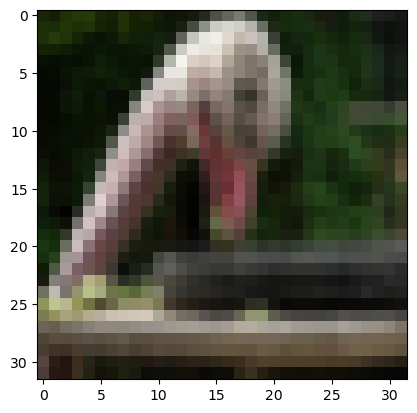

In [4]:
plt.imshow(X_train[400])
print(y_train[400])

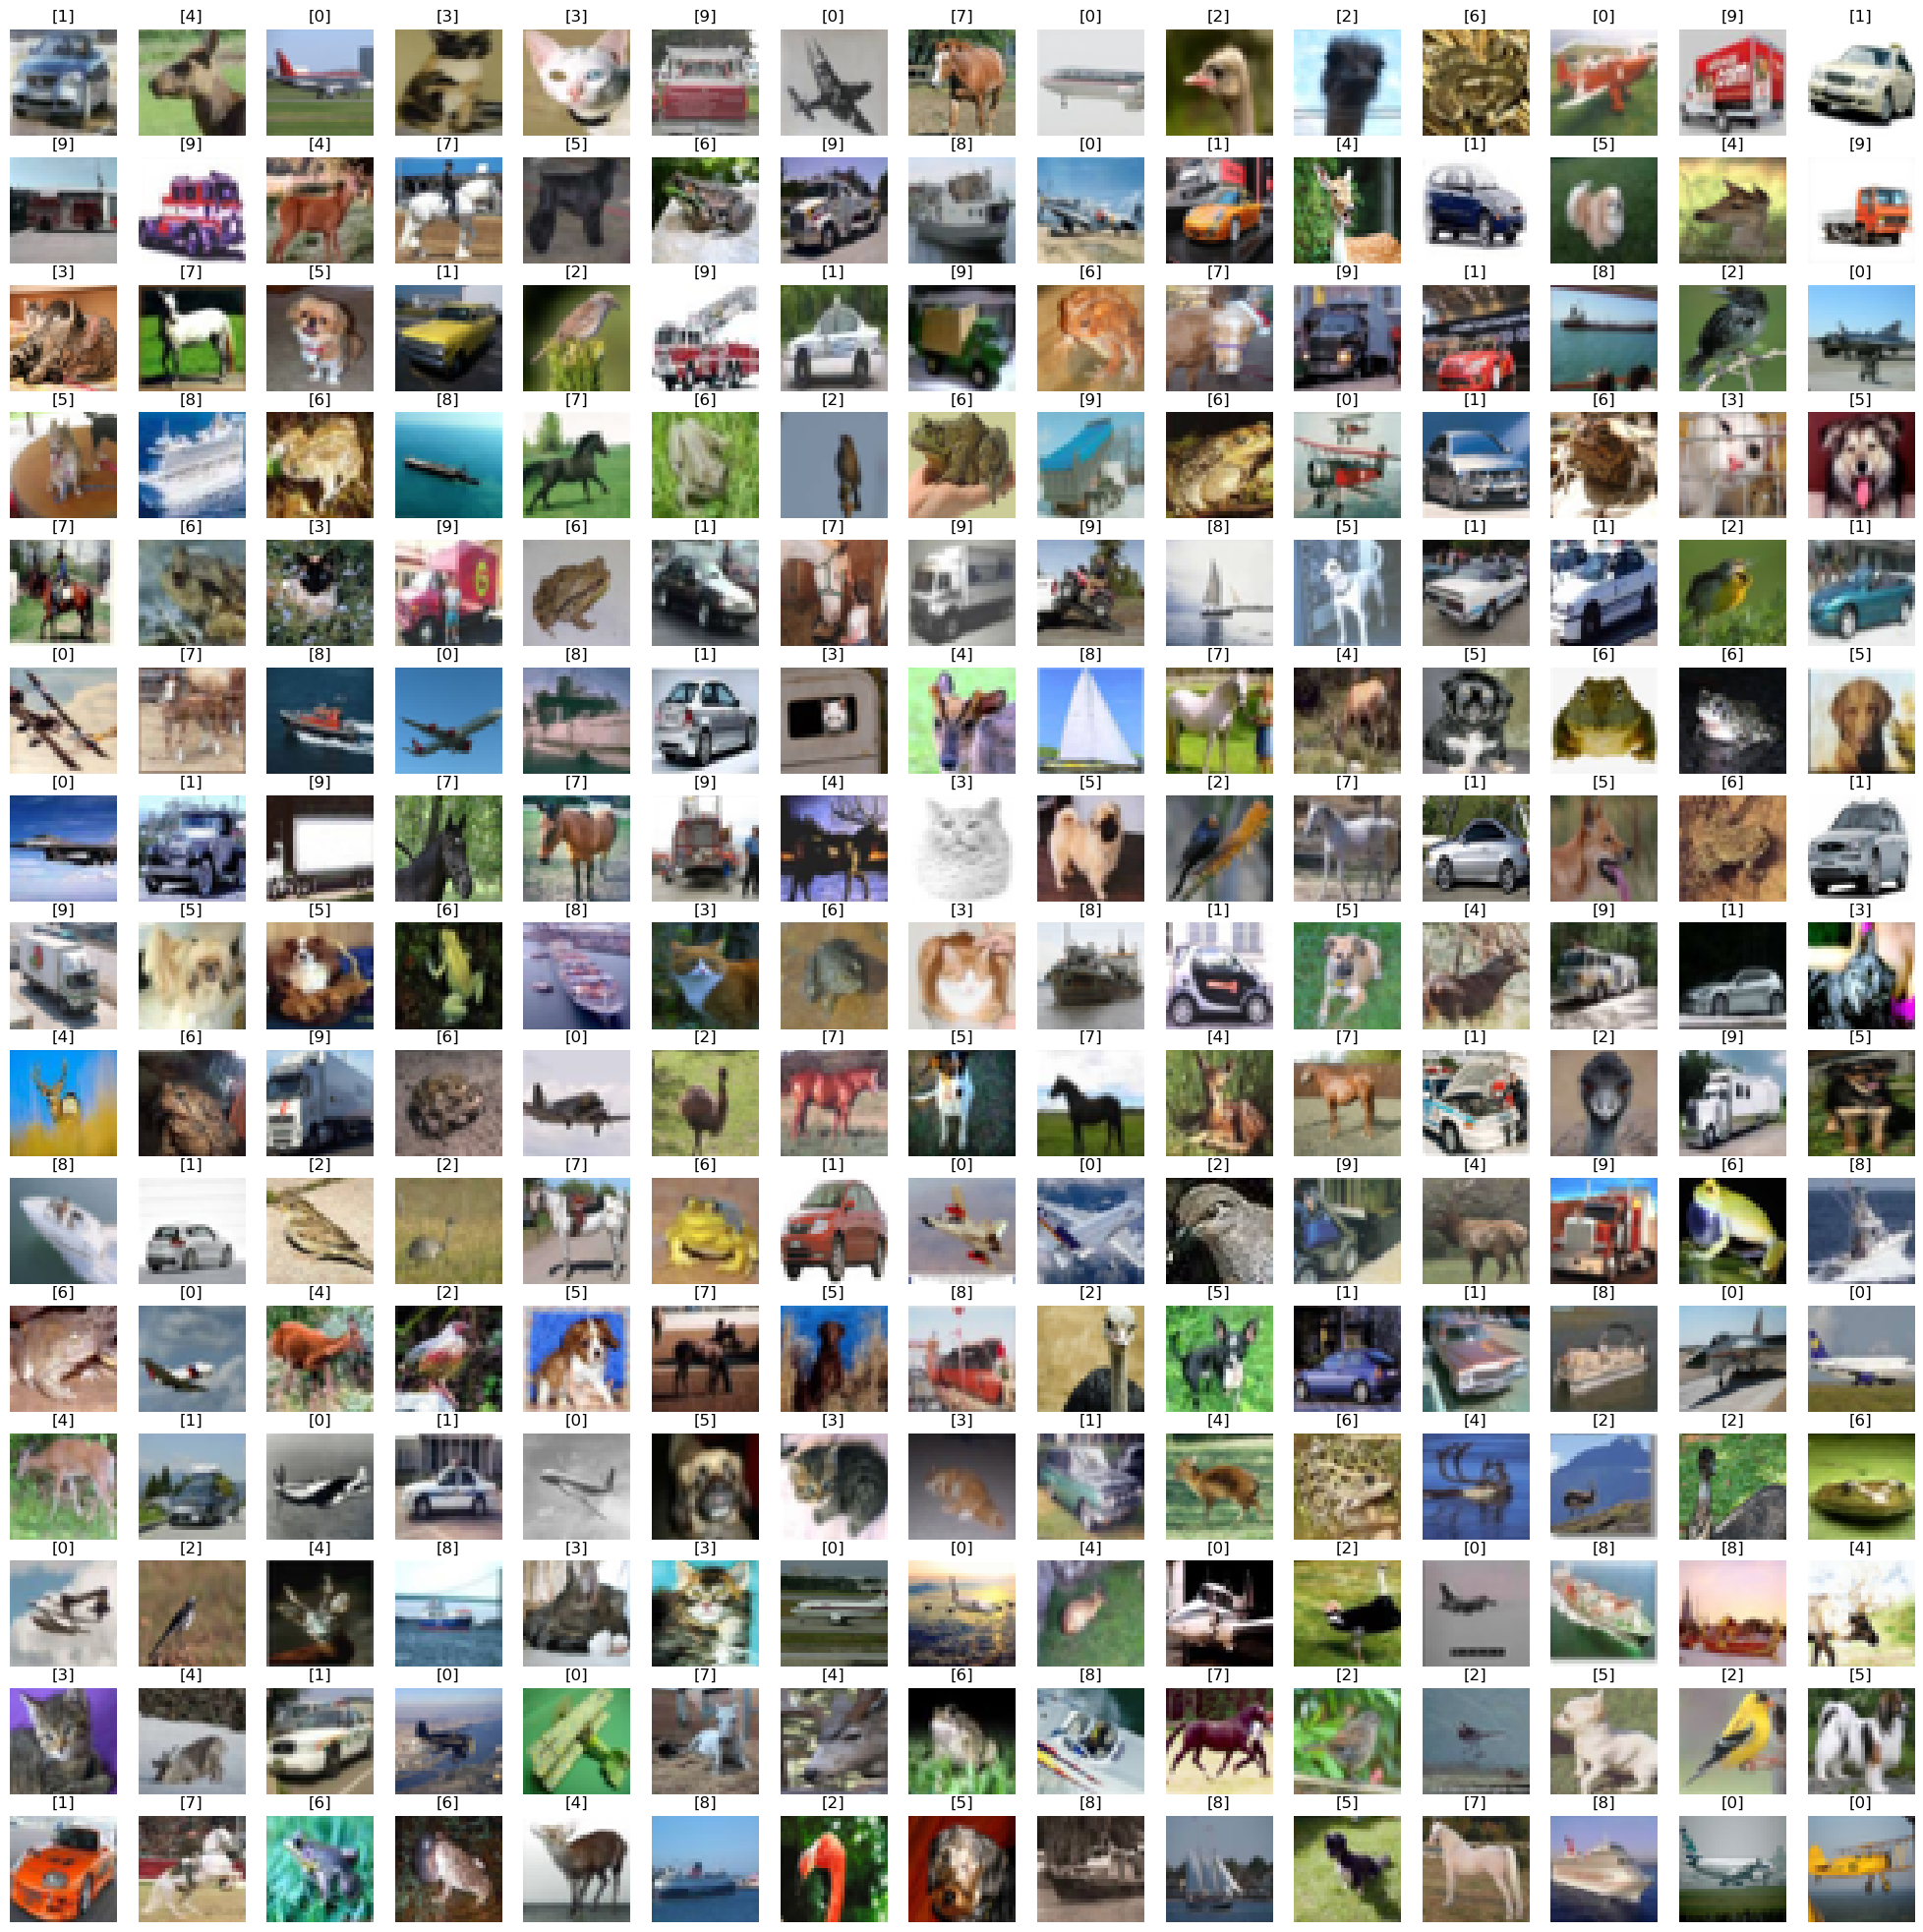

In [5]:
W_grid = 15
L_grid = 15
fig, axes = plt.subplots(L_grid, W_grid,figsize= (25,25))

n_training = len(X_train)

for i in range(0,L_grid*W_grid):
    index = np.random.randint(0,n_training)
    axes.flat[i].imshow(X_train[index])
    axes.flat[i].set_title(y_train[index])
    axes.flat[i].axis('off')

In [6]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

In [7]:
number_cat = 10
import keras
y_test = keras.utils.to_categorical(y_test,number_cat)
y_train = keras.utils.to_categorical(y_train,number_cat)


In [8]:
X_test = X_test/255
X_train = X_train/255

In [9]:
Input_shape = X_train.shape[1:]

In [10]:
print("X_train shape: ",X_train.shape)
print("X_test shape: ",X_test.shape)
print("y_test shape: ",y_test.shape)
print("y_test shape: ",y_test.shape)

X_train shape:  (50000, 32, 32, 3)
X_test shape:  (10000, 32, 32, 3)
y_test shape:  (10000, 10)
y_test shape:  (10000, 10)


In [11]:
from keras.models import Sequential
from keras.layers import Conv2D,AveragePooling2D,MaxPooling2D, Flatten, Dropout,Dense
from keras.optimizers import Adam
from keras.callbacks import TensorBoard

In [12]:
cnn_model = Sequential()
cnn_model.add(Conv2D(filters = 64, kernel_size = (3,3), activation = 'relu',input_shape= Input_shape))
cnn_model.add(Conv2D(filters =64, kernel_size = (3,3), activation = 'relu'))
cnn_model.add(MaxPooling2D(2,2))
cnn_model.add(Dropout(0.4))

cnn_model.add(Conv2D(filters = 32 , kernel_size= (3,3), activation = 'relu'))
cnn_model.add(Conv2D(filters = 32, kernel_size= (3,3), activation = 'relu'))
cnn_model.add(MaxPooling2D(2,2))
cnn_model.add(Dropout(0.2))

cnn_model.add(Flatten())

cnn_model.add(Dense(124,'relu'))
cnn_model.add(Dense(124,'relu'))

cnn_model.add(Dense(10,'softmax'))

D:\Downloads\New folder\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
from keras.optimizers import RMSprop
cnn_model.compile(loss="categorical_crossentropy",optimizer= keras.optimizers.RMSprop( 0.001))

In [14]:
history = cnn_model.fit(X_train,y_train, batch_size = 30,epochs = 32,shuffle = True)

Epoch 1/32
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 47s 27ms/step - loss: 1.6345
Epoch 2/32
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 56s 34ms/step - loss: 1.2318
Epoch 3/32
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 59s 36ms/step - loss: 1.0674
Epoch 4/32
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 60s 36ms/step - loss: 0.9788
Epoch 5/32
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 62s 37ms/step - loss: 0.9233
Epoch 6/32
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 61s 36ms/step - loss: 0.8929
Epoch 7/32
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 61s 37ms/step - loss: 0.8936
Epoch 8/32
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 61s 37ms/step - loss: 0.8897
Epoch 9/32
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 62s 37ms/step - loss: 0.8818
Epoch 10/32
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 61s 37ms/step - loss: 0.8751
Epoch 11/32
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 61s 37ms/step - loss: 0.8730
Epoch 12/32
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 61s 37ms/step - loss: 0.8702
Epoch 13/32
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 61s 37ms/step - loss: 0.8728
Epoch 14/32
1667/1667 ━━━━━━━━━━━━━━━━━━━━ 62s 37ms/step - loss: 0.8743
E

In [15]:
print("X_train shape: ",X_train.shape)
print("X_test shape: ",X_test.shape)
print("Y_train shape: ",y_train.shape)
print("Y_test shape: ",y_test.shape)

X_train shape:  (50000, 32, 32, 3)
X_test shape:  (10000, 32, 32, 3)
Y_train shape:  (50000, 10)
Y_test shape:  (10000, 10)


In [16]:

print("X_test : ",X_test.shape)

print("Y_test : ",y_test.shape)

X_test :  (10000, 32, 32, 3)
Y_test :  (10000, 10)


In [17]:
eval = cnn_model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 1.2889


In [18]:
predicted_classes = np.argmax(cnn_model.predict(X_test), axis=1)
predicted_classes

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step


array([8, 8, 8, ..., 5, 1, 7], dtype=int64)

In [19]:
y_test = np.argmax(y_test, axis=1)
y_test

array([3, 8, 8, ..., 5, 1, 7], dtype=int64)

In [20]:
y_test

array([3, 8, 8, ..., 5, 1, 7], dtype=int64)

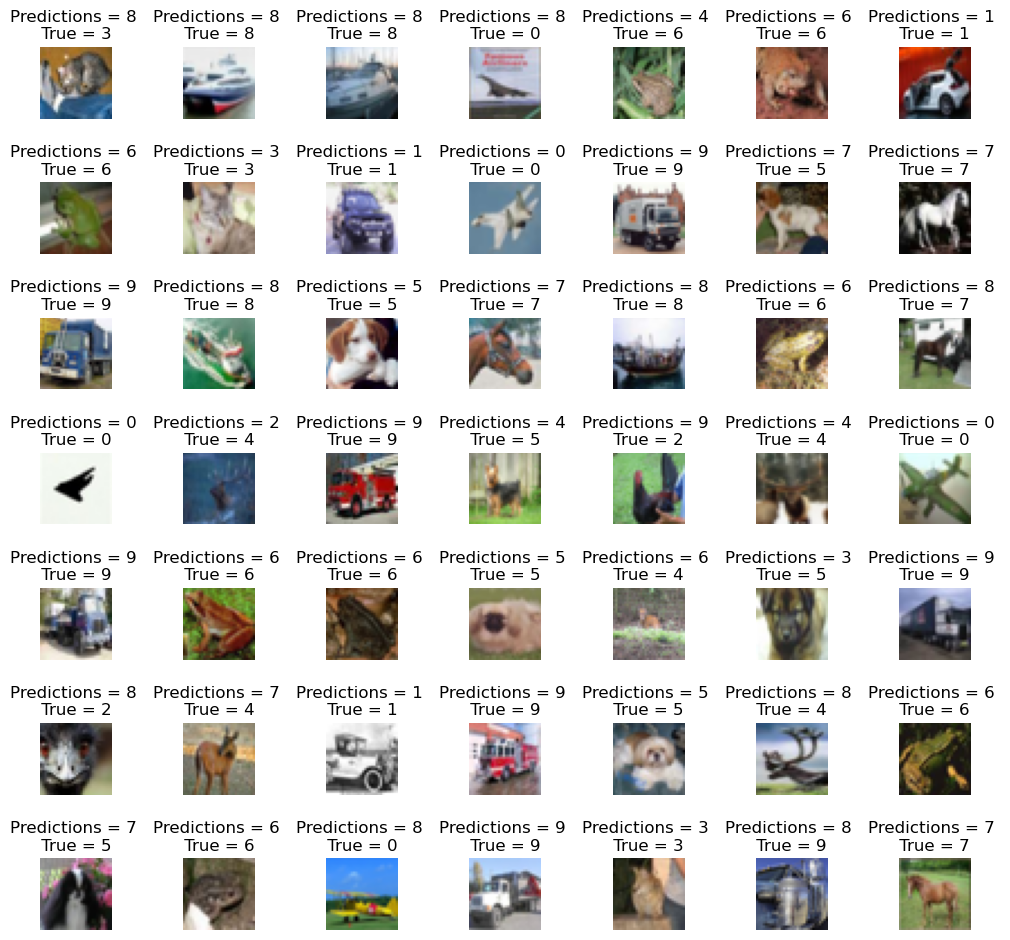

In [21]:
L = 7
W=7
fig,axes= plt.subplots(L,W,figsize=(12,12))
axes = axes.ravel()
for i in range(0,L*W):
    axes[i].imshow(X_test[i])
    axes[i].set_title('Predictions = {} \n True = {} '.format(predicted_classes[i],y_test[i]))
    axes.flat[i].axis('off')

plt.subplots_adjust(wspace = 1)

<Axes: >

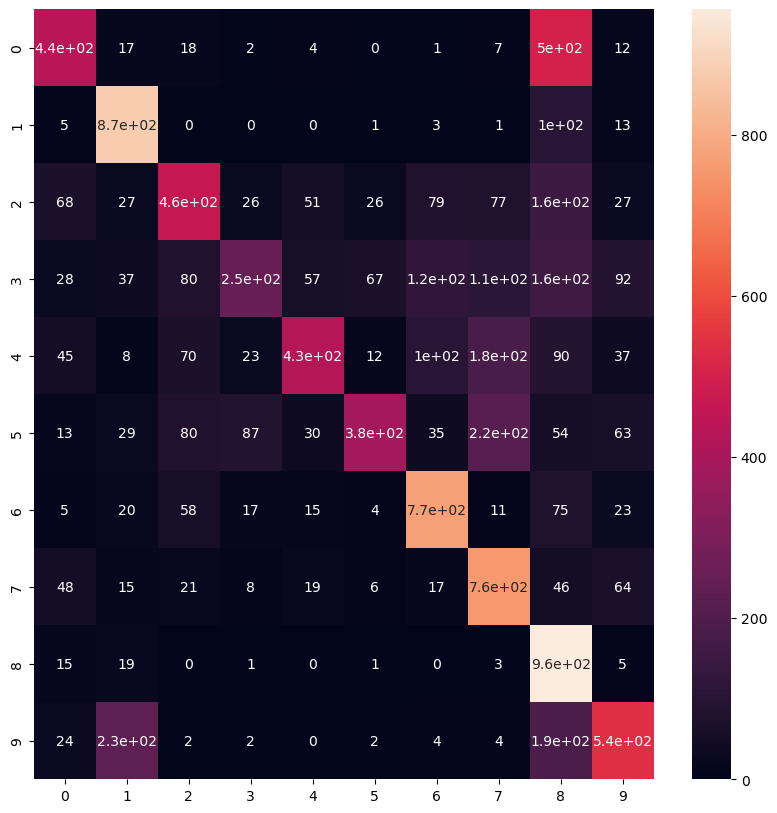

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, predicted_classes)
cm
plt.figure(figsize = (10, 10))
sns.heatmap(cm, annot = True)

In [23]:
import os
dir = os.path.join(os.getcwd(),'saved_models')
if not os.path.isdir (dir):
    os.makedirs(dir)
model_path = os.path.join(dir,'keras_ciphar_10_trained.keras')
cnn_model.save(model_path)

In [ ]:
import keras
from keras.datasets import cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()


In [ ]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

In [ ]:
n = 12
X_train_sample = X_train[:n]

In [ ]:


# dataget_train = ImageDataGenerator(rotation_range = 90)
# dataget_train = ImageDataGenerator(vertical_flip=True)
#dataget_train = ImageDataGenerator(height_shift_range=3)
dataget_train = ImageDataGenerator(brightness_range=(1,3))


dataget_train.fit(X_train_sample)

In [25]:

from PIL import Image
import numpy as np

fig = plt.figure(figsize = (20,2))
for x_batch in dataget_train.flow(X_train_sample, batch_size = n):
     for i in range(0,n):
            ax = fig.add_subplot(1, n, i+1)
            # Convert numpy array to PIL Image and display it
            # Ensure the array is in the right format (uint8) and shape
            img_array = np.uint8(x_batch[i] * 255)  # Scale to 0-255 if normalized
            ax.imshow(img_array)  # imshow can handle numpy arrays directly
     fig.suptitle('Augmented images (rotated 90 degrees)')
     plt.show()
     break

NameError: name 'dataget_train' is not defined

<Figure size 2000x200 with 0 Axes>

In [26]:

data_gen = ImageDataGenerator(
                            rotation_range = 90,
                            width_shift_range = 0.1,
                            horizontal_flip = True,
                            vertical_flip = True
                             )

In [27]:
data_gen.fit(X_train)

In [31]:
scr = cnn_model.fit(data_gen.flow(X_train,y_train,batch_size=32),epochs=1)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 43ms/step - loss: 1.6670


In [ ]:
cnn_model.evaluate(scr[0])

In [36]:
import os

dir = os.path.join(os.getcwd(),'saved_models')

if not os.path.isdir(dir):
    os.mkdir(dir)

model_path = os.path.join(dir,"Image Augmentation.keras")
cnn_model.save(model_path)